In [71]:
import sys

import matplotlib.pyplot
import matplotlib.ticker
import numpy
import pandas

sys.path.insert(0, "..")
from runner.utils import load_benchmark_metadata

# Load the results and metadata

In [72]:
# Read the latest results for all benchmarks.
all_results = pandas.read_csv("../results/benchmark_results.csv")

# Load the metadata of the benchmarks.
all_metadata = load_benchmark_metadata("../results/metadata.yaml")

# Add selected metadata columns to the results dataframe.
all_results["Variables"] = [
    all_metadata.loc[b, "Num. variables"] for b in all_results["bench-size"]
]
all_results["Constraints"] = [
    all_metadata.loc[b, "Num. constraints"] for b in all_results["bench-size"]
]
all_results["Problem class"] = [
    all_metadata.loc[b, "Problem class"] for b in all_results["bench-size"]
]

# Display the first few rows of the results dataframe.
all_results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version,Benchmark1,Variables,Constraints,Problem class
0,TIMES-GEO-global-netzero,31-20ts,gurobi,13.0.0,2025.0,ok,optimal,30621.769838,17795.476,2.173686e+08,...,2025-12-12 19:27:23.962157,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,gurobi-13.0.0,TIMES-GEO-global-netzero,5422595,5063755,LP
1,TIMES-GEO-global-netzero,31-20ts,highs-hipo,1.12.0-hipo,2025.0,warning,Not Set,64715.836039,14280.740,NaN,...,2025-12-13 04:01:38.198589,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-hipo-1.12.0-hipo,TIMES-GEO-global-netzero,5422595,5063755,LP
2,TIMES-GEO-global-netzero,31-20ts,highs-ipx,1.12.0-hipo,2025.0,warning,Not Set,70080.397365,9782.604,NaN,...,2025-12-13 22:03:17.152733,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-ipx-1.12.0-hipo,TIMES-GEO-global-netzero,5422595,5063755,LP
3,TIMES-GEO-global-netzero,31-20ts,highs,1.12.0,2025.0,ER,unknown,62869.744979,17229.104,0.000000e+00,...,2025-12-14 17:34:17.922231,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,highs-1.12.0,TIMES-GEO-global-netzero,5422595,5063755,LP
4,TIMES-GEO-global-netzero,31-20ts,scip,10.0.0,2025.0,TO,Timeout,86400.000000,39357.552,NaN,...,2025-12-15 11:05:58.727551,c4-highmem-16,europe-north2-b,90fca5f,TIMES-GEO-global-netzero-31-20ts,scip-10.0.0,TIMES-GEO-global-netzero,5422595,5063755,LP


In [73]:
# Read the results of the pypsa-de-elec scaling benchmark.
pypsa_de_elec_results = pandas.read_csv("../results/pypsa_de_elec_scaling.csv")

# Change the solver name of "highs-ipm" to "highs-ipx".
pypsa_de_elec_results["Solver"] = pypsa_de_elec_results["Solver"].replace(
    {"highs-ipm": "highs-ipx"}
)

# Print the name of the benchmark instances.
pypsa_de_elec_results["bench-size"].sort_values().unique().tolist()

['pypsa-de-elec-10-1h',
 'pypsa-de-elec-12-1h',
 'pypsa-de-elec-14-1h',
 'pypsa-de-elec-16-1h',
 'pypsa-de-elec-18-1h',
 'pypsa-de-elec-2-1h',
 'pypsa-de-elec-20-1h',
 'pypsa-de-elec-22-1h',
 'pypsa-de-elec-24-1h',
 'pypsa-de-elec-26-1h',
 'pypsa-de-elec-28-1h',
 'pypsa-de-elec-30-1h',
 'pypsa-de-elec-32-1h',
 'pypsa-de-elec-34-1h',
 'pypsa-de-elec-36-1h',
 'pypsa-de-elec-38-1h',
 'pypsa-de-elec-4-1h',
 'pypsa-de-elec-40-1h',
 'pypsa-de-elec-42-1h',
 'pypsa-de-elec-44-1h',
 'pypsa-de-elec-46-1h',
 'pypsa-de-elec-48-1h',
 'pypsa-de-elec-50-1h',
 'pypsa-de-elec-52-1h',
 'pypsa-de-elec-54-1h',
 'pypsa-de-elec-56-1h',
 'pypsa-de-elec-58-1h',
 'pypsa-de-elec-6-1h',
 'pypsa-de-elec-60-1h',
 'pypsa-de-elec-8-1h']

In [74]:
# Add selected metadata columns to the pypsa-de-elec results dataframe.
pypsa_de_elec_results["Variables"] = [
    all_metadata.loc[b, "Num. variables"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Constraints"] = [
    all_metadata.loc[b, "Num. constraints"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Problem class"] = [
    all_metadata.loc[b, "Problem class"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Temporal resolution"] = pypsa_de_elec_results["Size"].apply(
    lambda x: x.split("-")[1]
)
pypsa_de_elec_results["Spatial resolution"] = pypsa_de_elec_results["Size"].apply(
    lambda x: int(x.split("-")[0])
)

# Display the first few rows of the pypsa-de-elec results dataframe.
pypsa_de_elec_results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version,Variables,Constraints,Problem class,Temporal resolution,Spatial resolution
0,pypsa-de-elec,6-1h,cbc,2.10.12,2024.0,ok,optimal,34388.135925,2060.520,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,cbc-2.10.12,1384151,2943457,LP,1h,6
1,pypsa-de-elec,6-1h,gurobi,13.0.0,2025.0,ok,optimal,61.905031,3985.364,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,gurobi-13.0.0,1384151,2943457,LP,1h,6
2,pypsa-de-elec,6-1h,highs-hipo,1.12.0-hipo,2025.0,ok,Optimal,928.050613,3082.216,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-hipo-1.12.0-hipo,1384151,2943457,LP,1h,6
3,pypsa-de-elec,6-1h,highs-ipx,1.12.0-hipo,2025.0,ok,Optimal,5965.808359,2206.776,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-ipm-1.12.0-hipo,1384151,2943457,LP,1h,6
4,pypsa-de-elec,6-1h,highs,1.12.0,2025.0,ok,optimal,2348.684605,4254.792,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-1.12.0,1384151,2943457,LP,1h,6


# Define color, marker, and name mappings for solvers

In [75]:
# Define the color map for the solvers.
color_map = {
    "cbc": "#F9CD5A",  # yellow
    "glpk": "#7C3AED",  # purple
    "gurobi": "#F66C49",  # red
    "highs": "#43BF94",  # green
    "highs-hipo": "#F759B8",  # magenta
    "highs-ipx": "#6D712E",  # green-brown
    "scip": "#3B82F6",  # blue
}

# Define the marker map for the solvers.
marker_map = {
    "cbc": "o",  # yellow
    "glpk": "s",  # purple
    "gurobi": "D",  # red
    "highs": "^",  # green
    "highs-hipo": "v",  # magenta
    "highs-ipx": "P",  # green-brown
    "scip": "X",  # blue
}

# Define the name map for the solvers.
name_map = {
    "cbc": "CBC",
    "glpk": "GLPK",
    "gurobi": "Gurobi with\ndefault options",
    "highs": "HiGHS-simplex",
    "highs-hipo": "HiGHS-HiPO$^*$",
    "highs-ipx": "HiGHS-IPX$^*$",
    "scip": "SCIP",
}

# Process and analyze the *pypsa-de-elec* results

In [76]:
# Make sure that all problems are linear programming problems.
assert (pypsa_de_elec_results["Problem class"] == "LP").all()

# Define the solvers to consider in the analysis.
pypsa_de_elec_solvers = ["gurobi", "highs", "highs-ipx", "highs-hipo"]

# Initialize a list to store the latest version for each solver.
latest_versions = []

for solver in pypsa_de_elec_solvers:
    # Filter results for the current solver.
    solver_results = pypsa_de_elec_results[
        pypsa_de_elec_results["Solver"] == solver
    ].copy()

    # Keep only the latest version of the solver.
    solver_results = solver_results[
        solver_results["Solver Release Year"]
        == solver_results["Solver Release Year"].max()
    ]

    # Append the results of the latest version to the list.
    latest_versions.append(solver_results)

# Concatenate the results of the latest versions of all solvers into a single DataFrame.
pypsa_de_elec_results = pandas.concat(latest_versions, ignore_index=True)

# Sort the results by spatial resolution.
pypsa_de_elec_results = pypsa_de_elec_results.sort_values(by="Spatial resolution")

In [77]:
# Identify the problems where the solver succeeded.
is_solved = (pypsa_de_elec_results["Status"] == "ok") | (
    (pypsa_de_elec_results["Status"] == "warning")
    & (~pypsa_de_elec_results["Objective Value"].isna())
)

# Extract the problems where the solver succeeded.
pypsa_de_elec_results_solved = pypsa_de_elec_results[is_solved].copy()

# Initialize a dictionary to store the largest speedup of HiGHS-HIPO over each solver.
largest_speedup = {
    solver: 0 for solver in pypsa_de_elec_solvers if solver != "highs-hipo"
}

# Calculate the largest speedup that HiGHS-HIPO achieves over all other solvers.
for problem in pypsa_de_elec_results_solved[
    pypsa_de_elec_results_solved["Solver"] == "highs-hipo"
]["bench-size"]:
    for solver in pypsa_de_elec_solvers:
        if (
            solver != "highs-hipo"
            and problem
            in pypsa_de_elec_results_solved[
                pypsa_de_elec_results_solved["Solver"] == solver
            ]["bench-size"].to_list()
        ):
            # Get the runtime of the current solver and HiGHS-HIPO for the current problem.
            solver_runtime = pypsa_de_elec_results_solved[
                (pypsa_de_elec_results_solved["bench-size"] == problem)
                & (pypsa_de_elec_results_solved["Solver"] == solver)
            ]["Runtime (s)"].values[0]
            hipo_runtime = pypsa_de_elec_results_solved[
                (pypsa_de_elec_results_solved["bench-size"] == problem)
                & (pypsa_de_elec_results_solved["Solver"] == "highs-hipo")
            ]["Runtime (s)"].values[0]

            # Compute the speedup of HiGHS-HIPO over the current solver.
            speedup = solver_runtime / hipo_runtime

            # Update the largest speedup if the current speedup is larger.
            if speedup > largest_speedup[solver]:
                largest_speedup[solver] = speedup

# Display the largest speedup of HiGHS-HIPO over each solver.
largest_speedup

{'gurobi': np.float64(0.1730538497975351),
 'highs': np.float64(12.978059939164792),
 'highs-ipx': np.float64(14.685711864241723)}

# Plot the runtime of the *pypsa-de-elec* problems by solver as a function of the spatial resolution

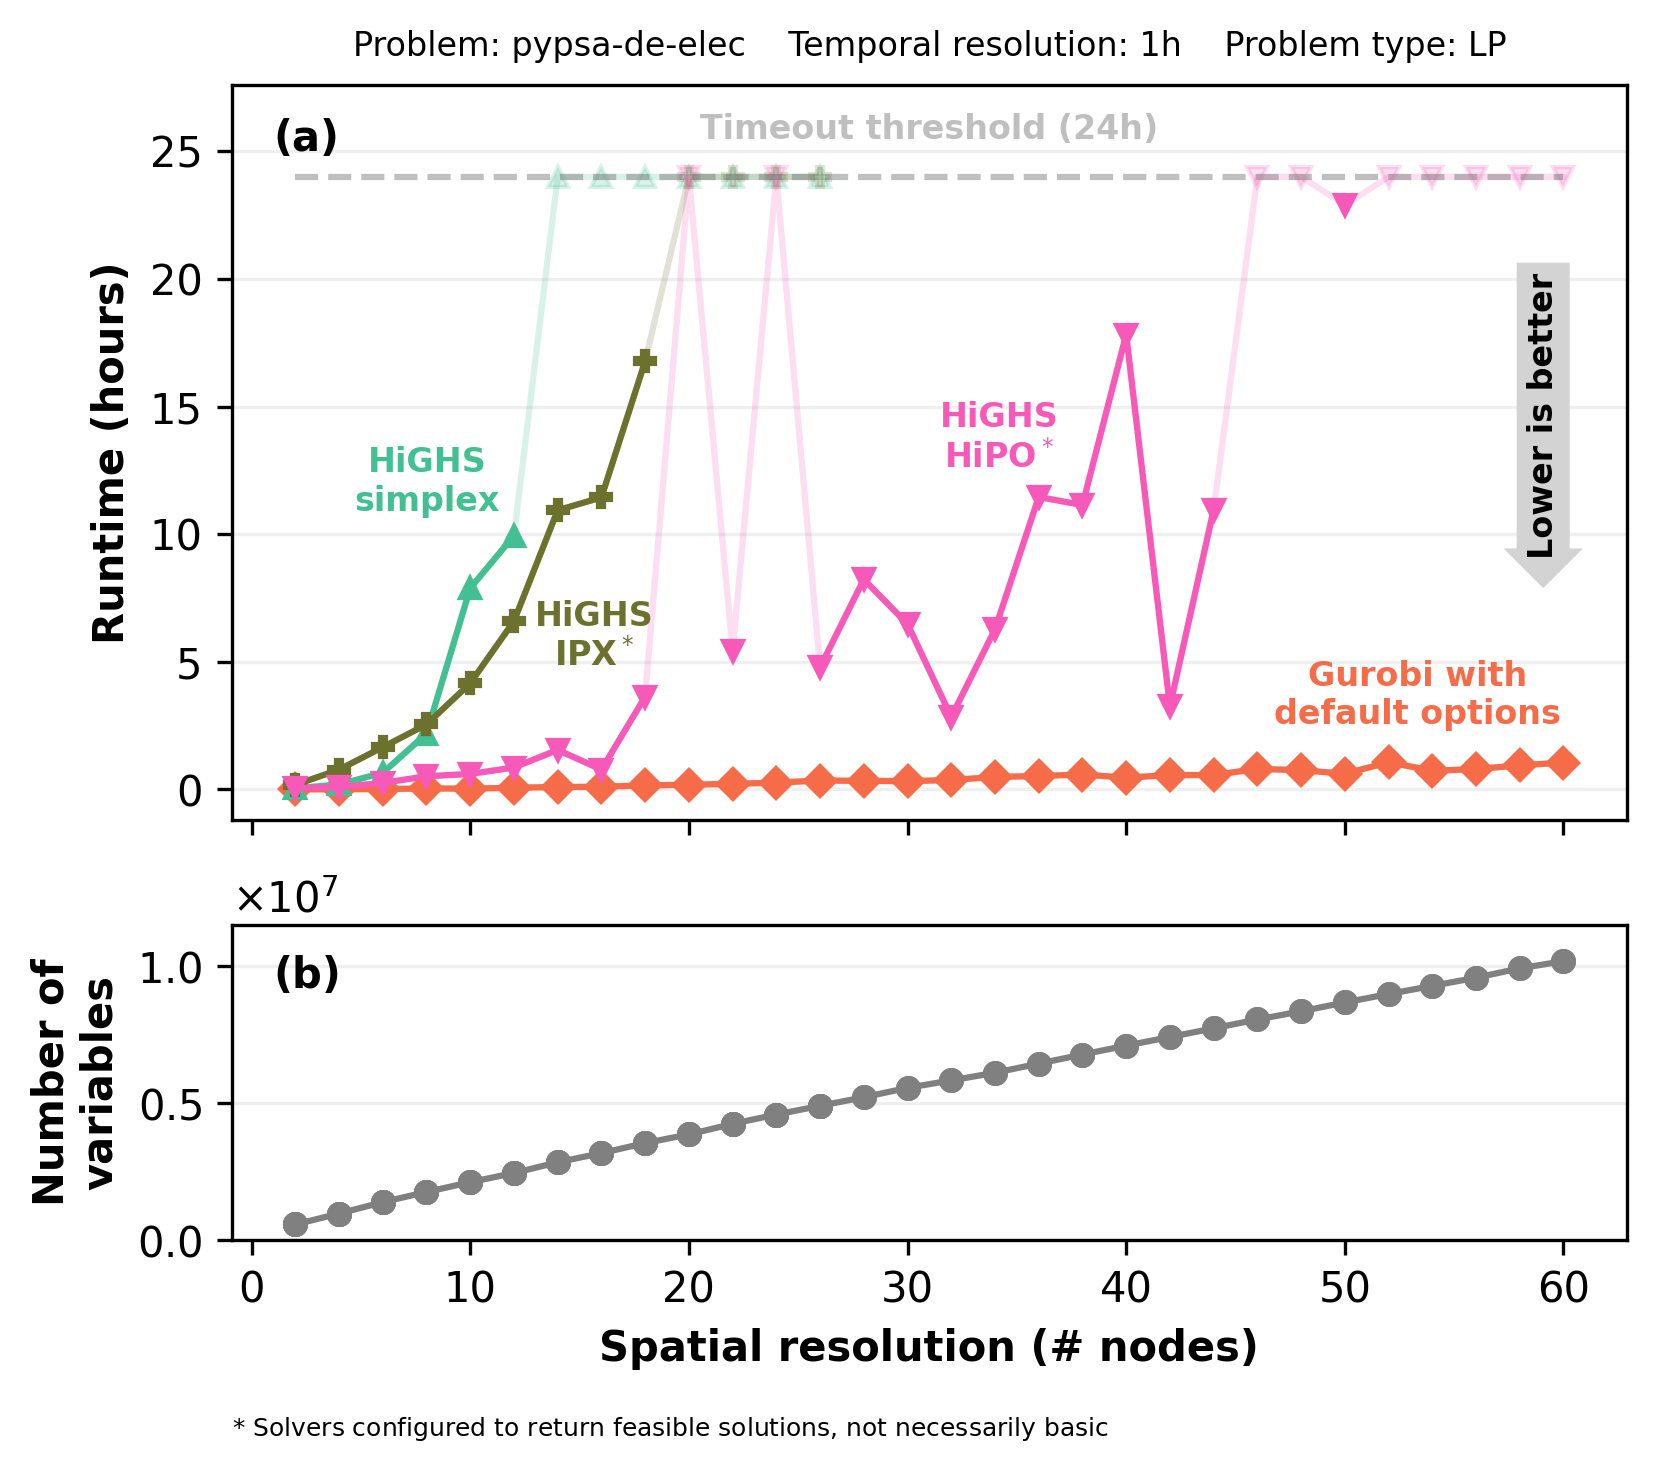

In [78]:
# Define the timeout threshold in hours.
timeout_threshold = 24

# Initialize the figure and axis.
fig, axs = matplotlib.pyplot.subplots(
    2,
    1,
    figsize=(6, 5),
    dpi=300,
    sharex=True,
    gridspec_kw={"height_ratios": [0.7, 0.3]},
)

# Define the x-axis limits based on the spatial resolution of the benchmark instances.
x_axis_limits = (2, 60)

for solver in pypsa_de_elec_solvers:
    # Get the results for the current solver and sort by spatial resolution.
    solver_results = pypsa_de_elec_results[
        pypsa_de_elec_results["Solver"] == solver
    ].copy()

    # Convert from seconds to hours for better readability.
    solver_results["Runtime (s)"] = solver_results["Runtime (s)"] / 3600

    # Identify the problems where the solver did not succeed.
    is_not_solved = solver_results["Status"].isin(["TO", "OOM", "ER"]) | (
        (solver_results["Status"] == "warning")
        & (solver_results["Objective Value"].isna())
    )

    # For the problems not solved, set the runtime to the timeout threshold.
    # This will appear in the faint lines.
    solver_results.loc[is_not_solved, "Runtime (s)"] = timeout_threshold

    # Plot the runtime of the current solver with the timeout values in faint lines.
    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # For the problems not solved, set the runtime to NaN.
    # This will make them not appear in the main lines.
    solver_results.loc[is_not_solved, "Runtime (s)"] = numpy.nan

    # Plot the runtime of the current solver without the timeout values.
    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

# Add a horizontal dashed line for the timeout threshold.
axs[0].hlines(
    timeout_threshold,
    xmin=x_axis_limits[0],
    xmax=x_axis_limits[1],
    linestyles="dashed",
    alpha=0.5,
    color="grey",
)
axs[0].text(
    (x_axis_limits[0] + x_axis_limits[1]) / 2,
    timeout_threshold * 1.05,
    "Timeout threshold (24h)",
    ha="center",
    va="bottom",
    fontsize=8,
    alpha=0.5,
    color="grey",
    weight="bold",
)

# Set the axis labels, ticks, scale, grid, and legend.
axs[0].set_ylabel("Runtime (hours)", weight="bold")
axs[0].set_ylim(top=timeout_threshold * 1.15)
axs[0].grid(axis="y", alpha=0.2)

# Add an annotation close to each line to indicate the solver name.
axs[0].text(
    0.85,
    0.17,
    "Gurobi with\ndefault options",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("gurobi", None),
    weight="bold",
    fontsize=8,
)
axs[0].text(
    0.14,
    0.46,
    "HiGHS\nsimplex",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("highs", None),
    weight="bold",
    fontsize=8,
)
axs[0].text(
    0.26,
    0.25,
    "HiGHS\nIPX$^*$",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("highs-ipx", None),
    weight="bold",
    fontsize=8,
)
axs[0].text(
    0.55,
    0.52,
    "HiGHS\nHiPO$^*$",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("highs-hipo", None),
    weight="bold",
    fontsize=8,
)

# Add an arrow and text to indicate that lower runtime is better.
axs[0].text(
    0.94,
    0.55,
    "Lower is better",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[0].text(0.03, 0.91, "(a)", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Plot the number of variables by spatial resolution in the top panel.
resolutions_to_plot = pypsa_de_elec_results[
    pypsa_de_elec_results["Spatial resolution"].isin(
        range(x_axis_limits[0], x_axis_limits[1] + 2)
    )
]
axs[1].plot(
    resolutions_to_plot["Spatial resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="grey",
)
axs[1].set_ylabel("Number of\nvariables", weight="bold")
axs[1].set_ylim(0, 1.15e7)
axs[1].set_xlabel("Spatial resolution (# nodes)", weight="bold")
axs[1].grid(axis="y", alpha=0.2)
axs[1].yaxis.get_major_formatter().set_useMathText(True)

# Add the panel letter.
axs[1].text(0.03, 0.8, "(b)", transform=axs[1].transAxes, fontsize=10, weight="bold")

# Add a note to explain that IPX and HiPO are configured to return feasible solutions, not necessarily basic.
axs[1].text(
    0,
    -0.6,
    "$*$ Solvers configured to return feasible solutions, not necessarily basic",
    transform=axs[1].transAxes,
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Add a note about the benchmark instance.
axs[0].text(
    0.5,
    1.03,
    "Problem: pypsa-de-elec    Temporal resolution: 1h    Problem type: LP",
    ha="center",
    va="bottom",
    transform=axs[0].transAxes,
    fontsize=8,
)

# Save the figure.
fig.savefig(
    "analyze-hipo-results__solver-runtime-by-spatial-resolution.png",
    bbox_inches="tight",
    dpi=300,
)

# Process and analyze all results

In [79]:
# Keep only LP problems.
all_results = all_results[all_results["Problem class"] == "LP"]

# Initialize a list to store the latest version for each solver.
latest_versions = []

for solver in all_results["Solver"].unique():
    # Filter results for the current solver.
    solver_results = all_results[all_results["Solver"] == solver].copy()

    # Keep only the latest version of the solver.
    solver_results = solver_results[
        solver_results["Solver Release Year"]
        == solver_results["Solver Release Year"].max()
    ]

    # Append the results of the latest version to the list.
    latest_versions.append(solver_results)

# Concatenate the results of the latest versions of all solvers into a single DataFrame.
all_results = pandas.concat(latest_versions, ignore_index=True)

# Sort the results by becnh-size and solver.
all_results = all_results.sort_values(by=["bench-size", "Solver"]).reset_index(
    drop=True
)

In [80]:
# Define the buckets for the number of variables.
buckets = {
    "$10^2$-$10^3$": (1e2, 1e3),
    "$10^3$-$10^4$": (1e3, 1e4),
    "$10^4$-$10^5$": (1e4, 1e5),
    "$10^5$-$10^6$": (1e5, 1e6),
    "$10^6$-$10^7$": (1e6, 1e7),
    "$10^7$-$10^8$": (1e7, 1e8),
}

# Define the solvers to consider in the analysis.
solvers = ["gurobi", "highs", "highs-ipx", "highs-hipo"]

# Define the features to compute for each bucket.
features = ["num_problems", "fraction_solved", "sgm_runtime", "relative_sgm_runtime"]

# Define the shift to apply to the runtime when computing the SGM runtime.
sgm_shift = 10

# Initialize the bucket stats dictionary.
bucket_stats = {
    feature: {solver: {bucket: numpy.nan for bucket in buckets} for solver in solvers}
    for feature in features
}

for solver in solvers:
    # Filter results for the current solver.
    solver_results = all_results[all_results["Solver"] == solver].copy()

    for bucket, (lower, upper) in buckets.items():
        # Filter results for the current bucket.
        bucket_results = solver_results[
            (solver_results["Variables"] >= lower)
            & (solver_results["Variables"] < upper)
        ]

        # Compute the number of problems.
        bucket_stats["num_problems"][solver][bucket] = len(bucket_results)

        # Identify the problems where the solver succeeded.
        is_solved = (bucket_results["Status"] == "ok") | (
            (bucket_results["Status"] == "warning")
            & (~bucket_results["Objective Value"].isna())
        )

        # Extract the problems where the solver succeeded.
        bucket_results_solved = bucket_results[is_solved]

        # Compute the fraction of problems solved.
        if len(bucket_results) > 0:
            bucket_stats["fraction_solved"][solver][bucket] = len(
                bucket_results_solved
            ) / len(bucket_results)

        # Penalize the runtime of unsolved problems by multiplying the timeout threshold by 2.
        bucket_results["Runtime (s)"] = bucket_results["Runtime (s)"].where(
            is_solved, 2 * bucket_results["Timeout"]
        )

        # Compute the SGM runtime.
        bucket_stats["sgm_runtime"][solver][bucket] = (
            numpy.exp(numpy.mean(numpy.log(bucket_results["Runtime (s)"] + sgm_shift)))
            - sgm_shift
        )

for bucket in buckets:
    # Find the solver with the largest SGM runtime in the current bucket.
    reference_solver = max(
        solvers, key=lambda s: bucket_stats["sgm_runtime"][s][bucket]
    )

    for solver in solvers:
        # Compute the relative SGM runtime of each solver with respect to the reference solver.
        bucket_stats["relative_sgm_runtime"][solver][bucket] = (
            bucket_stats["sgm_runtime"][reference_solver][bucket]
            / bucket_stats["sgm_runtime"][solver][bucket]
        )

In [81]:
# Display the fraction of problems solved in each bucket for each solver.
bucket_stats["fraction_solved"]

{'gurobi': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.6585365853658537,
  '$10^6$-$10^7$': 0.9056603773584906,
  '$10^7$-$10^8$': 0.6666666666666666},
 'highs': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.3902439024390244,
  '$10^6$-$10^7$': 0.18867924528301888,
  '$10^7$-$10^8$': 0.0},
 'highs-ipx': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.8048780487804879,
  '$10^6$-$10^7$': 0.5471698113207547,
  '$10^7$-$10^8$': 0.16666666666666666},
 'highs-hipo': {'$10^2$-$10^3$': 1.0,
  '$10^3$-$10^4$': 0.8,
  '$10^4$-$10^5$': 1.0,
  '$10^5$-$10^6$': 0.8536585365853658,
  '$10^6$-$10^7$': 0.5849056603773585,
  '$10^7$-$10^8$': 0.0}}

In [82]:
# Display the relative SGM runtime of each solver in each bucket.
bucket_stats["relative_sgm_runtime"]

{'gurobi': {'$10^2$-$10^3$': np.float64(1.0),
  '$10^3$-$10^4$': np.float64(1.0035303781861016),
  '$10^4$-$10^5$': np.float64(1.4239257817094142),
  '$10^5$-$10^6$': np.float64(1.8560898849938914),
  '$10^6$-$10^7$': np.float64(71.31288087252203),
  '$10^7$-$10^8$': np.float64(12.552342359079432)},
 'highs': {'$10^2$-$10^3$': np.float64(7.290265391209703),
  '$10^3$-$10^4$': np.float64(1.020217078931284),
  '$10^4$-$10^5$': np.float64(1.0),
  '$10^5$-$10^6$': np.float64(1.0),
  '$10^6$-$10^7$': np.float64(1.0),
  '$10^7$-$10^8$': np.float64(1.0)},
 'highs-ipx': {'$10^2$-$10^3$': np.float64(3.3851959252055606),
  '$10^3$-$10^4$': np.float64(1.0468876997244614),
  '$10^4$-$10^5$': np.float64(1.820641876416889),
  '$10^5$-$10^6$': np.float64(3.0483683433414304),
  '$10^6$-$10^7$': np.float64(2.4818008169054786),
  '$10^7$-$10^8$': np.float64(1.1447099758649475)},
 'highs-hipo': {'$10^2$-$10^3$': np.float64(1.0048527430069027),
  '$10^3$-$10^4$': np.float64(1.0),
  '$10^4$-$10^5$': np.flo

In [83]:
# Get the number of problems in each bucket for each solver.
num_problems_per_bucket = {
    solver: list(stats.values())
    for solver, stats in bucket_stats["num_problems"].items()
}
num_problems_per_bucket

{'gurobi': [3, 5, 25, 41, 53, 6],
 'highs': [3, 5, 25, 41, 53, 6],
 'highs-ipx': [3, 5, 25, 41, 53, 6],
 'highs-hipo': [3, 5, 25, 41, 53, 6]}

In [84]:
# Get the total problems run by each solver.
{solver: sum(stats.values()) for solver, stats in bucket_stats["num_problems"].items()}

{'gurobi': 133, 'highs': 133, 'highs-ipx': 133, 'highs-hipo': 133}

In [85]:
# Get the total problems successfully solved by each solver.
{
    solver: int(
        sum(
            bucket_stats["fraction_solved"][solver][bucket]
            * bucket_stats["num_problems"][solver][bucket]
            for bucket in buckets
        )
    )
    for solver in solvers
}

{'gurobi': 111, 'highs': 58, 'highs-ipx': 95, 'highs-hipo': 98}

In [86]:
# Identify the problems where the solver succeeded.
is_solved = (all_results["Status"] == "ok") | (
    (all_results["Status"] == "warning") & (~all_results["Objective Value"].isna())
)

# Extract the problems where the solver succeeded.
solved_problems = all_results[is_solved].copy()

# Initialize a dictionary to store the largest speedup of HiGHS-HiPO over each solver.
largest_speedup = {solver: 0 for solver in solvers if solver != "highs-hipo"}

# Calculate the largest speedup that HiGHS-HiPO achieves over all other solvers.
for problem in solved_problems[solved_problems["Solver"] == "highs-hipo"]["bench-size"]:
    for solver in solvers:
        if (
            solver != "highs-hipo"
            and problem
            in solved_problems[solved_problems["Solver"] == solver][
                "bench-size"
            ].to_list()
        ):
            # Get the runtime of the current solver and HiGHS-HiPO for the current problem.
            solver_runtime = solved_problems[
                (solved_problems["bench-size"] == problem)
                & (solved_problems["Solver"] == solver)
            ]["Runtime (s)"].values[0]
            hipo_runtime = solved_problems[
                (solved_problems["bench-size"] == problem)
                & (solved_problems["Solver"] == "highs-hipo")
            ]["Runtime (s)"].values[0]

            # Compute the speedup of HiGHS-HiPO over the current solver.
            speedup = solver_runtime / hipo_runtime

            # Update the largest speedup if the current speedup is larger.
            if speedup > largest_speedup[solver]:
                largest_speedup[solver] = speedup

# Display the largest speedup of HiGHS-HiPO over each solver.
largest_speedup

{'gurobi': np.float64(7.600905283916516),
 'highs': np.float64(52.96458500255611),
 'highs-ipx': np.float64(10.052998076268205)}

In [87]:
# Get the poblems with more than 10^7 variables.
all_results[all_results["Variables"] > 1e7]["bench-size"].unique().tolist()

['SWITCH-China-open-model-32-433ts',
 'genx-elec_co2-15-168h',
 'genx-elec_trex-15-168h',
 'genx-elec_trex_co2-15-168h',
 'pypsa-de-sec-trex_copt-50-1h',
 'pypsa-de-sec-trex_vopt-50-1h']

In [88]:
# Calculate the total number of problems solved by any solver.
all_results.loc[is_solved, "bench-size"].nunique()

127

In [89]:
# Identify the problems where the solver is open-source and not HiGHS-HiPO.
solver_is_open_source_excluding_hipo = all_results["Solver"].isin(
    ["highs", "highs-ipx", "scip", "cbc", "glpk"]
)

# Calculate the total number of problems solved by any open-source solver excluding HiGHS-HiPO.
all_results.loc[
    is_solved & solver_is_open_source_excluding_hipo, "bench-size"
].nunique()

99

In [90]:
# Identify the problems where the solver is open-source.
solver_is_open_source = all_results["Solver"].isin(
    ["highs", "highs-ipx", "highs-hipo", "scip", "cbc", "glpk"]
)

# Calculate the total number of problems solved by any open-source solver.
all_results.loc[is_solved & solver_is_open_source, "bench-size"].nunique()

106

In [91]:
# Identify the problems where the solver is Gurobi.
solver_is_gurobi = all_results["Solver"] == "gurobi"

# Calculate the total number of problems solved by Gurobi.
all_results.loc[is_solved & solver_is_gurobi, "bench-size"].nunique()

111

# For each problem size and solver, plot the number of problems, the fraction of solved problems, and the SGM of the runtime

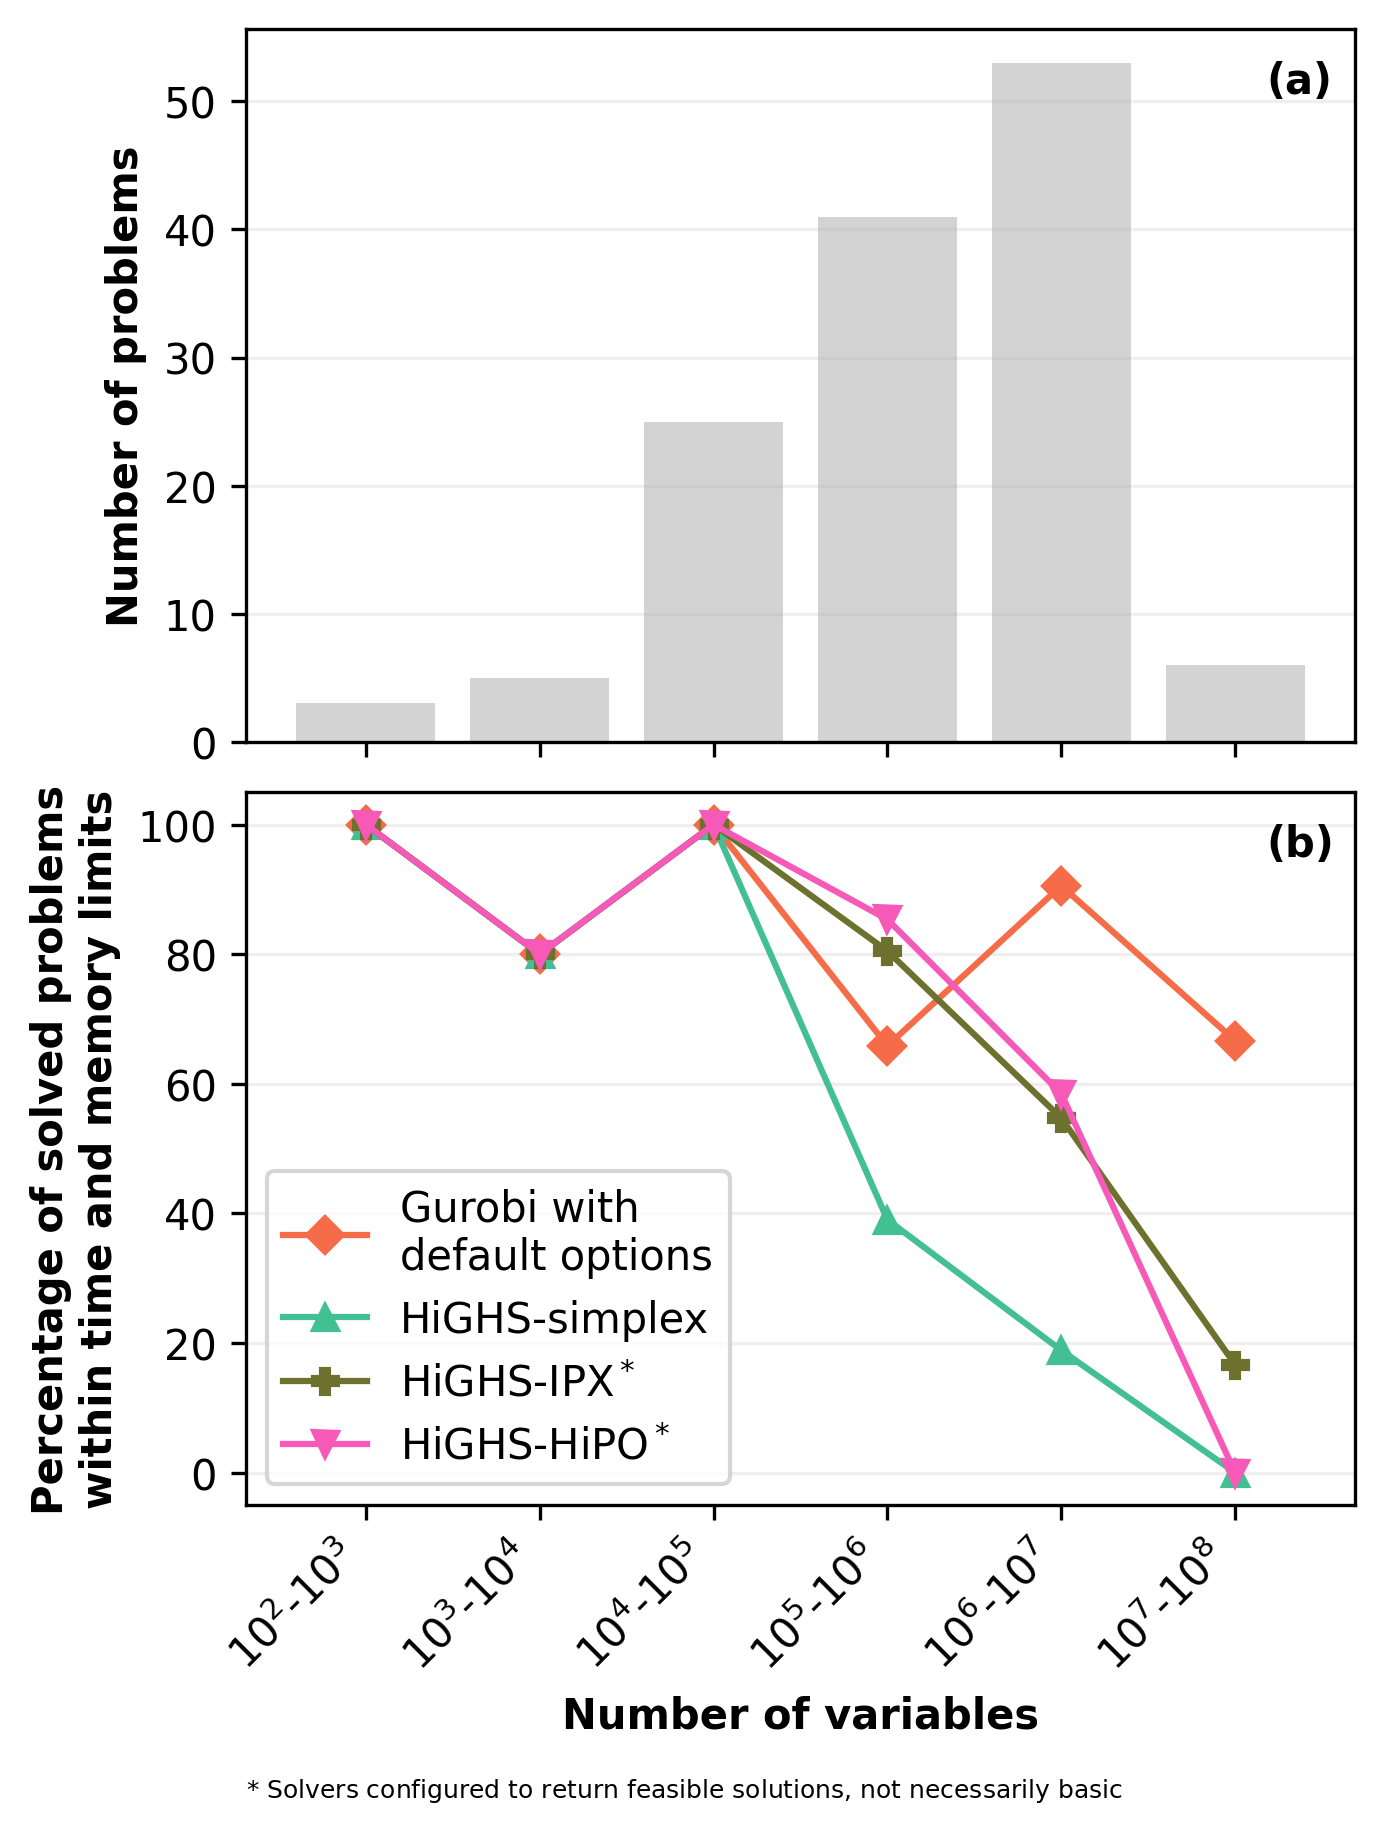

In [92]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    2, 1, figsize=(4.5, 6), dpi=300, sharex=True, constrained_layout=True
)

# If all solvers have the same number of problems in each bucket, use a bar plot for the number of problems in each bucket. Otherwise, use a line plot.
if len(set(tuple(v) for v in num_problems_per_bucket.values())):
    # Add a bar plot for the number of problems in each bucket.
    axs[0].bar(
        range(len(buckets)),
        list(num_problems_per_bucket.values())[0],
        color="lightgrey",
        label="Number of problems",
    )
    axs[0].set_ylabel("Number of problems", weight="bold")
    axs[0].grid(axis="y", alpha=0.2)
else:
    # Add a line plot for the number of problems in each bucket.
    for i, (solver, stats) in enumerate(bucket_stats["num_problems"].items()):
        buckets_list = list(stats.keys())
        values = list(stats.values())
        axs[0].plot(
            range(len(buckets_list)),
            values,
            marker=marker_map.get(solver, None),
            label=name_map.get(solver, solver),
            color=color_map.get(solver, None),
        )
    axs[0].set_ylabel("Number of problems", weight="bold")
    axs[0].grid(axis="y", alpha=0.2)

# Add the panel letter.
axs[0].text(0.92, 0.91, "(a)", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Add a line plot for the percentage of problems solved in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["fraction_solved"].items()):
    buckets_list = stats.keys()
    values = numpy.array(list(stats.values())) * 100
    axs[1].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1].set_ylabel(
    "Percentage of solved problems\nwithin time and memory limits", weight="bold"
)
axs[1].set_xticks(
    range(len(buckets)), labels=list(buckets.keys()), rotation=45, ha="right"
)
axs[1].set_xlabel("Number of variables", weight="bold")
axs[1].grid(axis="y", alpha=0.2)
axs[1].legend(loc="lower left")

# Add the panel letter.
axs[1].text(0.92, 0.91, "(b)", transform=axs[1].transAxes, fontsize=10, weight="bold")

# Add a note to explain that IPX and HiPO are configured to return feasible solutions, not necessarily basic.
axs[1].text(
    0,
    -0.4,
    "$*$ Solvers configured to return feasible solutions, not necessarily basic",
    transform=axs[1].transAxes,
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig(
    "analyze-hipo-results__fraction-solved-by-problem-size.png",
    bbox_inches="tight",
    dpi=300,
)

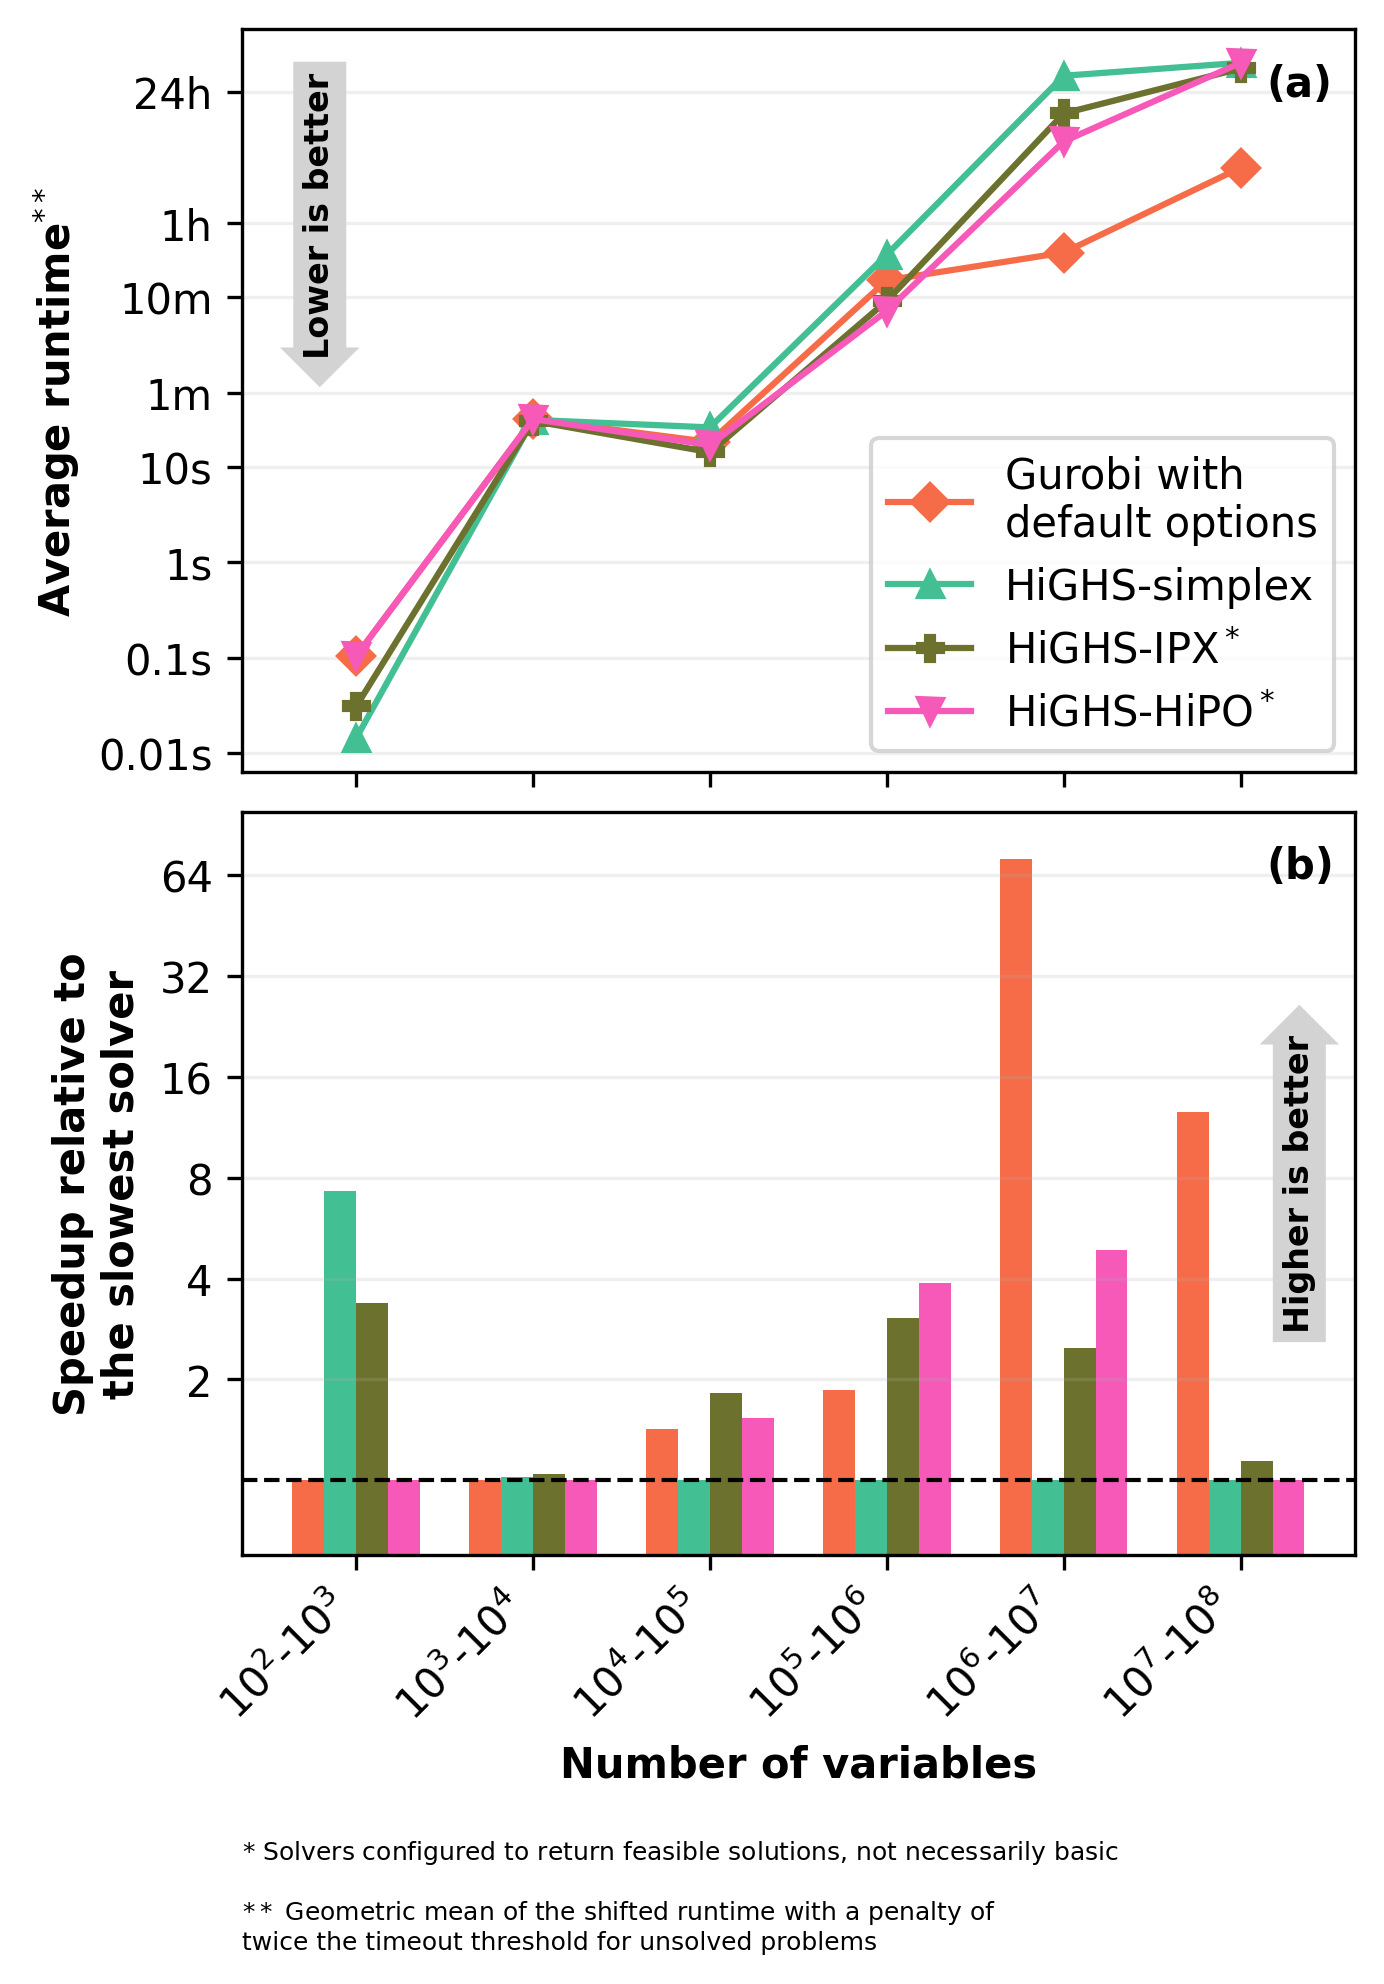

In [93]:
# Initialize the figure and axes for the plot.
fig, axs = matplotlib.pyplot.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=300, sharex=True, constrained_layout=True
)

# Add a line plot for the SGM runtime in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["sgm_runtime"].items()):
    buckets_list = list(stats.keys())
    values = list(stats.values())
    axs[0].plot(
        range(len(buckets_list)),
        values,
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[0].set_yscale("log")
axs[0].minorticks_off()
axs[0].set_ylabel("Average runtime$^{**}$", weight="bold")
axs[0].set_yticks(
    [0.01, 0.1, 1, 10, 60, 600, 3600, 86400],
    ["0.01s", "0.1s", "1s", "10s", "1m", "10m", "1h", "24h"],
)
axs[0].legend(loc="lower right")
axs[0].grid(axis="y", alpha=0.2)
axs[0].text(
    0.07,
    0.75,
    "Lower is better",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[0].text(0.92, 0.91, "(a)", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Add a bar plot for the relative SGM runtime in each bucket.
for i, (solver, stats) in enumerate(bucket_stats["relative_sgm_runtime"].items()):
    buckets_list = list(stats.keys())
    values = list(stats.values())
    axs[1].bar(
        [j + -0.27 + 0.18 * i for j in range(len(buckets_list))],
        values,
        width=0.18,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )
axs[1].axhline(1, color="black", linestyle="--", linewidth=1)
axs[1].set_yscale("log", base=2)
axs[1].set_ylim(0.6, 99)
axs[1].set_yticks([2, 4, 8, 16, 32, 64], ["2", "4", "8", "16", "32", "64"])
axs[1].minorticks_off()
axs[1].set_ylabel("Speedup relative to\nthe slowest solver", weight="bold")
axs[1].set_xticks(range(len(buckets_list)), buckets_list, rotation=45, ha="right")
axs[1].set_xlabel("Number of variables", weight="bold")
axs[1].grid(axis="y", alpha=0.2)
axs[1].text(
    0.95,
    0.5,
    "Higher is better",
    transform=axs[1].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="rarrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[1].text(0.92, 0.91, "(b)", transform=axs[1].transAxes, fontsize=10, weight="bold")

# Add a note to explain that IPX and HiPO are configured to return feasible solutions, not necessarily basic.
axs[1].text(
    0,
    -0.4,
    "$*$ Solvers configured to return feasible solutions, not necessarily basic",
    transform=axs[1].transAxes,
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)


# Add a note to explain the meaning of the SGM runtime.
axs[1].text(
    0,
    -0.5,
    "$**$ Geometric mean of the shifted runtime with a penalty of\ntwice the timeout threshold for unsolved problems",
    transform=axs[1].transAxes,
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

# Save the figure.
fig.savefig(
    "analyze-hipo-results__sgm-runtime-by-problem-size.png",
    bbox_inches="tight",
    dpi=300,
)